# Proyecto de Business Intelligence — COVID-19 Global Dataset
## Fase 3: Preparación y Modelado de Datos

**Dataset fuente:** [Corona Virus Report — Kaggle (imdevskp)](https://www.kaggle.com/datasets/imdevskp/corona-virus-report)  
**Archivo utilizado:** `covid_19_clean_complete.csv`  

---

### Contexto de continuidad

Esta fase continúa directamente el trabajo de las fases anteriores:

- **Fase 1** identificó el problema central y las tres preguntas clave, realizó EDA completo y detectó que el dataset presenta distribuciones fuertemente asimétricas, un 70.1% de nulos en `Province/State` (no problemáticos), y una consistencia interna aceptable entre variables epidemiológicas.
- **Fase 2** validó estadísticamente las dos hipótesis: **H1** (CFR difiere entre regiones OMS) fue confirmada vía ANOVA (p = 0.046); **H2** (timing de llegada correlaciona con CFR) no fue confirmada vía Pearson (p = 0.055, marginal).

La Fase 3 consolida estos insumos en un modelo de datos limpio, estructurado y listo para ser consumido por el dashboard de Power BI y el análisis de storytelling.

---
## 1. Configuración del Entorno

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from itertools import combinations
import warnings

warnings.filterwarnings('ignore')

# ── Estilo global (consistente con fases anteriores) ─────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi'        : 120,
    'font.family'       : 'DejaVu Sans',
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})
ALPHA    = 0.05
NUM_COLS = ['Confirmed', 'Deaths', 'Recovered', 'Active']
COLORS   = ['steelblue', 'crimson', 'seagreen', 'darkorange']

print('Entorno configurado.')

Entorno configurado.


---
## 2. Carga y Reconstrucción de Insumos de Fases Anteriores

Para garantizar trazabilidad y reproducibilidad, se reconstruye aquí el mismo pipeline de carga y derivación de variables utilizado en las fases 1 y 2, sin duplicar análisis.

In [2]:
# ── Carga del dataset base ────────────────────────────────────────────────────
df = pd.read_csv('../Data/covid_19_clean_complete.csv', parse_dates=['Date'])

latest_date = df['Date'].max()
latest      = df[df['Date'] == latest_date]

# ── Snapshot por país al cierre (igual que en Fase 2) ────────────────────────
ct = (
    latest.groupby('Country/Region')[['Confirmed', 'Deaths', 'Recovered', 'Active']]
    .sum().reset_index()
)
ct = ct[ct['Confirmed'] >= 500].copy()          # Filtro de robustez (Fase 2)
ct['CFR'] = ct['Deaths'] / ct['Confirmed'] * 100

ct_r = ct.merge(
    df[['Country/Region', 'WHO Region']].drop_duplicates(), on='Country/Region'
)

# ── Timing (igual que en Fase 2) ─────────────────────────────────────────────
first_case = (
    df[df['Confirmed'] > 0]
    .groupby('Country/Region')['Date'].min()
    .reset_index()
    .rename(columns={'Date': 'First_Case_Date'})
)
first_case['Days_from_start'] = (
    first_case['First_Case_Date'] - first_case['First_Case_Date'].min()
).dt.days
timing_df = ct_r.merge(first_case, on='Country/Region')

print(f'Dataset base          : {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Fecha de corte        : {latest_date.date()}')
print(f'Países en análisis    : {len(ct_r)} (con ≥ 500 casos confirmados)')
print(f'Regiones OMS          : {ct_r["WHO Region"].nunique()}')
print(f'Países con timing     : {len(timing_df)}')

Dataset base          : 49,068 filas × 10 columnas
Fecha de corte        : 2020-07-27
Países en análisis    : 154 (con ≥ 500 casos confirmados)
Regiones OMS          : 6
Países con timing     : 154


---
## 3. Limpieza y Transformación de Datos

La Fase 1 ya documentó los problemas de calidad del dataset. Aquí se aplican las correcciones de forma sistemática y se registran todas las decisiones.

### 3.1 Tratamiento de valores nulos

In [3]:
# ── Diagnóstico de nulos ──────────────────────────────────────────────────────
nulos = df.isnull().sum()
nulos_pct = (df.isnull().mean() * 100).round(2)
df_nulos = pd.DataFrame({'Valores nulos': nulos, '% del total': nulos_pct})
print('Nulos por columna:')
display(df_nulos[df_nulos['Valores nulos'] > 0])

print()
print('Decisión de tratamiento:')
print('  • Province/State (70.1% nulo): se conserva sin imputar.')
print('    Los nulos indican que el país reporta como unidad única, no por provincia.')
print('    El análisis agrega a nivel Country/Region, por lo que la columna no afecta.')
print('  • WHO Region (0 nulos en filas completas): sin acción.')

Nulos por columna:


,Valores nulos,% del total
Province/State,34404,70.11



Decisión de tratamiento:
  • Province/State (70.1% nulo): se conserva sin imputar.
    Los nulos indican que el país reporta como unidad única, no por provincia.
    El análisis agrega a nivel Country/Region, por lo que la columna no afecta.
  • WHO Region (0 nulos en filas completas): sin acción.


In [4]:
# ── Aplicación del tratamiento ────────────────────────────────────────────────
df_clean = df.copy()

# Province/State: se rellena con el nombre del país para trazabilidad en Power BI
df_clean['Province/State'] = df_clean['Province/State'].fillna(df_clean['Country/Region'])

# WHO Region: limpieza de espacios
df_clean['WHO Region'] = df_clean['WHO Region'].str.strip()

# Variables numéricas: los negativos ocasionales son errores de reporte;
# se clip a 0 (no pueden existir valores negativos de casos)
for col in NUM_COLS:
    n_neg = (df_clean[col] < 0).sum()
    if n_neg > 0:
        print(f'  ⚠ {col}: {n_neg} valores negativos → corregidos a 0')
    df_clean[col] = df_clean[col].clip(lower=0)

print(f'\nNulos totales tras limpieza: {df_clean.isnull().sum().sum()}')
print('Limpieza aplicada.')

  ⚠ Active: 18 valores negativos → corregidos a 0

Nulos totales tras limpieza: 0
Limpieza aplicada.


### 3.2 Manejo de duplicados y consistencia interna

In [5]:
# ── Duplicados ────────────────────────────────────────────────────────────────
dups = df_clean.duplicated().sum()
print(f'Filas duplicadas exactas: {dups}')
if dups > 0:
    df_clean = df_clean.drop_duplicates()
    print(f'  → Eliminados. Nuevo shape: {df_clean.shape}')
else:
    print('  → Sin duplicados. No se requiere acción.')

print()

# ── Consistencia: Confirmed = Deaths + Recovered + Active ────────────────────
df_clean['_residuo'] = df_clean['Confirmed'] - df_clean['Deaths'] - \
                        df_clean['Recovered'] - df_clean['Active']

inconsistentes = (df_clean['_residuo'].abs() > 1).sum()
pct_inconsist  = inconsistentes / len(df_clean) * 100
print(f'Filas con inconsistencia interna (|residuo| > 1): {inconsistentes} ({pct_inconsist:.2f}%)')
print('  → Las inconsistencias provienen de diferencias en el timing de reporte entre')
print('    jurisdicciones. Se documentan pero no se corrigen para preservar los datos originales.')
print('  → En las métricas derivadas se usará siempre una sola fórmula consistente.')

df_clean.drop(columns=['_residuo'], inplace=True)

Filas duplicadas exactas: 0
  → Sin duplicados. No se requiere acción.

Filas con inconsistencia interna (|residuo| > 1): 17 (0.03%)
  → Las inconsistencias provienen de diferencias en el timing de reporte entre
    jurisdicciones. Se documentan pero no se corrigen para preservar los datos originales.
  → En las métricas derivadas se usará siempre una sola fórmula consistente.


### 3.3 Tratamiento de outliers

La Fase 1 identificó que ≈18% de los registros son outliers estadísticos por el criterio IQR. En un dataset epidemiológico, los valores extremos no son errores sino reflejo de la heterogeneidad entre países (tamaño poblacional, capacidad diagnóstica, densidad). **No se eliminan**, pero se documenta su naturaleza.

In [6]:
# ── Identificación de outliers por IQR en el snapshot de cierre ──────────────
def iqr_outliers(series, label):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    mask = (series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)
    paises = ct_r.loc[mask[mask].index, 'Country/Region'].tolist() if mask.sum() > 0 else []
    return pd.Series({
        'Variable'     : label,
        'Q1'           : round(Q1, 1),
        'Q3'           : round(Q3, 1),
        'Límite sup.'  : round(Q3 + 1.5 * IQR, 1),
        'N outliers'   : mask.sum(),
        '% del total'  : round(mask.mean() * 100, 1),
        'Países clave' : ', '.join(paises[:5]) + (' …' if len(paises) > 5 else '')
    })

outlier_report = pd.DataFrame([
    iqr_outliers(ct_r['Confirmed'].reset_index(drop=True), 'Confirmed'),
    iqr_outliers(ct_r['Deaths'].reset_index(drop=True),    'Deaths'),
    iqr_outliers(ct_r['Recovered'].reset_index(drop=True), 'Recovered'),
    iqr_outliers(ct_r['Active'].reset_index(drop=True),    'Active'),
    iqr_outliers(ct_r['CFR'].reset_index(drop=True),       'CFR'),
])
display(outlier_report)

print()
print('Decisión: los outliers se CONSERVAN.')
print('Justificación epidemiológica: EE.UU., Brasil e India concentran legitimamente')
print('gran parte de la carga pandémica mundial. Eliminarlos sesgaria el análisis.')
print('Para visualizaciones, se aplicará escala logarítmica cuando sea necesario.')

,Variable,Q1,Q3,Límite sup.,N outliers,% del total,Países clave
0,Confirmed,2374.2,60875.8,148628.0,20,13.0,"Argentina, Bangladesh, Brazil, Chile, Colombia …"
1,Deaths,51.0,1316.8,3215.4,26,16.9,"Belgium, Brazil, Canada, Chile, China …"
2,Recovered,1161.5,30103.2,73515.9,21,13.6,"Bangladesh, Brazil, Chile, China, Colombia …"
3,Active,668.5,12411.2,30025.4,27,17.5,"Argentina, Bangladesh, Belgium, Bolivia, Brazil …"
4,CFR,1.3,4.0,7.9,10,6.5,"Belgium, Chad, France, Hungary, Italy …"



Decisión: los outliers se CONSERVAN.
Justificación epidemiológica: EE.UU., Brasil e India concentran legitimamente
gran parte de la carga pandémica mundial. Eliminarlos sesgaria el análisis.
Para visualizaciones, se aplicará escala logarítmica cuando sea necesario.


---
## 4. Ingeniería de Variables

Se crean las variables derivadas necesarias para el análisis BI. Cada variable se justifica desde su utilidad epidemiológica y su relación con las hipótesis y preguntas formuladas.

In [7]:
# ────────────────────────────────────────────────────────────────────────────
# TABLA DE HECHOS: nivel (País × Fecha) — dataset completo transformado
# ────────────────────────────────────────────────────────────────────────────
df_hechos = df_clean.copy()

# V1. Nuevos casos diarios por país (diferencia respecto al día anterior)
df_hechos = df_hechos.sort_values(['Country/Region', 'Province/State', 'Date'])
df_hechos['New_Confirmed'] = (
    df_hechos.groupby(['Country/Region', 'Province/State'])['Confirmed']
    .diff().clip(lower=0)  # diff negativa = corrección de reporte → se trata como 0
)
df_hechos['New_Deaths'] = (
    df_hechos.groupby(['Country/Region', 'Province/State'])['Deaths']
    .diff().clip(lower=0)
)
df_hechos['New_Recovered'] = (
    df_hechos.groupby(['Country/Region', 'Province/State'])['Recovered']
    .diff().clip(lower=0)
)

# V2. CFR diaria acumulada (requiere al menos 1 confirmado)
df_hechos['CFR_daily'] = np.where(
    df_hechos['Confirmed'] > 0,
    df_hechos['Deaths'] / df_hechos['Confirmed'] * 100,
    np.nan
).round(4)

# V3. Tasa de recuperación diaria acumulada
df_hechos['Recovery_Rate_daily'] = np.where(
    df_hechos['Confirmed'] > 0,
    df_hechos['Recovered'] / df_hechos['Confirmed'] * 100,
    np.nan
).round(4)

# V4. Tasa de casos activos diaria
df_hechos['Active_Rate_daily'] = np.where(
    df_hechos['Confirmed'] > 0,
    df_hechos['Active'] / df_hechos['Confirmed'] * 100,
    np.nan
).round(4)

# V5. Media móvil de 7 días de nuevos casos (suaviza variabilidad de reporte)
df_hechos['MA7_New_Confirmed'] = (
    df_hechos.groupby(['Country/Region', 'Province/State'])['New_Confirmed']
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
).round(2)

df_hechos['MA7_New_Deaths'] = (
    df_hechos.groupby(['Country/Region', 'Province/State'])['New_Deaths']
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
).round(2)

print('Variables nuevas en df_hechos:')
nuevas_h = ['New_Confirmed','New_Deaths','New_Recovered',
            'CFR_daily','Recovery_Rate_daily','Active_Rate_daily',
            'MA7_New_Confirmed','MA7_New_Deaths']
print(df_hechos[['Country/Region','Date'] + nuevas_h].head(10).to_string(index=False))

Variables nuevas en df_hechos:
Country/Region       Date  New_Confirmed  New_Deaths  New_Recovered  CFR_daily  Recovery_Rate_daily  Active_Rate_daily  MA7_New_Confirmed  MA7_New_Deaths
   Afghanistan 2020-01-22            NaN         NaN            NaN        NaN                  NaN                NaN                NaN             NaN
   Afghanistan 2020-01-23            0.0         0.0            0.0        NaN                  NaN                NaN                0.0             0.0
   Afghanistan 2020-01-24            0.0         0.0            0.0        NaN                  NaN                NaN                0.0             0.0
   Afghanistan 2020-01-25            0.0         0.0            0.0        NaN                  NaN                NaN                0.0             0.0
   Afghanistan 2020-01-26            0.0         0.0            0.0        NaN                  NaN                NaN                0.0             0.0
   Afghanistan 2020-01-27            0.0     

In [8]:
# ────────────────────────────────────────────────────────────────────────────
# SNAPSHOT DE CIERRE: nivel (País) — variables al último día disponible
# ────────────────────────────────────────────────────────────────────────────
df_pais = ct_r.copy()

# V6. Tasa de Recuperación final
df_pais['Recovery_Rate'] = (
    df_pais['Recovered'] / df_pais['Confirmed'] * 100
).round(4)

# V7. Tasa de casos activos final (carga sanitaria al corte)
df_pais['Active_Rate'] = (
    df_pais['Active'] / df_pais['Confirmed'] * 100
).round(4)

# V8. Índice de Mortalidad Relativa: muertes por cada 100 recuperados
df_pais['IMR'] = np.where(
    df_pais['Recovered'] > 0,
    df_pais['Deaths'] / df_pais['Recovered'] * 100,
    np.nan
).round(4)

# V9. Timing de llegada (desde Fase 2)
df_pais = df_pais.merge(
    first_case[['Country/Region', 'First_Case_Date', 'Days_from_start']],
    on='Country/Region', how='left'
)

# V10. Categoría de tamaño de epidemia por cuartil de confirmados
df_pais['Epidemic_Size'] = pd.qcut(
    df_pais['Confirmed'], q=4,
    labels=['Bajo (Q1)', 'Moderado (Q2)', 'Alto (Q3)', 'Crítico (Q4)'],
    duplicates='drop'
)

nuevas_p = ['CFR','Recovery_Rate','Active_Rate','IMR','Days_from_start','Epidemic_Size']
print('Variables en df_pais (snapshot de cierre):')
display(df_pais[['Country/Region','WHO Region'] + nuevas_p].head(10))

Variables en df_pais (snapshot de cierre):


,Country/Region,WHO Region,CFR,Recovery_Rate,Active_Rate,IMR,Days_from_start,Epidemic_Size
0,Afghanistan,Eastern Mediterranean,3.499435,69.4868,27.0138,5.0361,33,Alto (Q3)
1,Albania,Europe,2.950820,56.2500,40.7992,5.2459,47,Moderado (Q2)
2,Algeria,Africa,4.157581,67.3399,28.5025,6.1740,34,Alto (Q3)
3,Andorra,Europe,5.733186,88.5336,5.7332,6.4757,40,Bajo (Q1)
4,Angola,Africa,4.315789,25.4737,70.2105,16.9421,58,Bajo (Q1)
5,Argentina,Americas,1.827185,43.3501,54.8227,4.2150,41,Crítico (Q4)
6,Armenia,Europe,1.901578,71.3159,26.7826,2.6664,39,Alto (Q3)
7,Australia,Western Pacific,1.091289,60.8443,38.0644,1.7936,4,Alto (Q3)
8,Austria,Europe,3.468236,88.7538,7.7780,3.9077,34,Alto (Q3)
9,Azerbaijan,Europe,1.389345,76.3384,22.2722,1.8200,39,Alto (Q3)


In [9]:
# ────────────────────────────────────────────────────────────────────────────
# AGREGADO REGIONAL: nivel (Región OMS)
# ────────────────────────────────────────────────────────────────────────────
df_region = df_pais.groupby('WHO Region').agg(
    Paises          = ('Country/Region', 'count'),
    Confirmados     = ('Confirmed',      'sum'),
    Muertes         = ('Deaths',         'sum'),
    Recuperados     = ('Recovered',      'sum'),
    Activos         = ('Active',         'sum'),
    CFR_media       = ('CFR',            'mean'),
    CFR_mediana     = ('CFR',            'median'),
    Recovery_media  = ('Recovery_Rate',  'mean'),
    Active_media    = ('Active_Rate',    'mean'),
    Days_media      = ('Days_from_start','mean'),
).reset_index()

# CFR real a nivel región (no promedio de promedios)
df_region['CFR_region']      = (df_region['Muertes']     / df_region['Confirmados'] * 100).round(4)
df_region['Recovery_region'] = (df_region['Recuperados'] / df_region['Confirmados'] * 100).round(4)
df_region['Active_region']   = (df_region['Activos']     / df_region['Confirmados'] * 100).round(4)

print('Vista agregada por Región OMS:')
display(df_region.sort_values('Confirmados', ascending=False))

Vista agregada por Región OMS:


,WHO Region,Paises,Confirmados,Muertes,Recuperados,Activos,CFR_media,CFR_mediana,Recovery_media,Active_media,Days_media,CFR_region,Recovery_region,Active_region
1,Americas,24,8837989,342681,4467914,4027394,3.307536,2.922906,56.386288,40.306171,42.875000,3.8774,50.5535,45.5691
3,Europe,52,3299295,211139,1993513,1094643,4.432686,3.248828,66.670242,28.897077,36.634615,6.3995,60.4224,33.1781
4,South-East Asia,7,1834824,41343,1156555,636926,1.606251,1.310642,70.962871,27.430871,21.142857,2.2532,63.0336,34.7132
2,Eastern Mediterranean,22,1490744,38339,1201400,251005,3.563603,1.821387,66.592718,29.843677,40.590909,2.5718,80.5906,16.8376
0,Africa,41,721416,12196,439380,269840,2.269995,1.687500,55.155278,42.574712,55.878049,1.6906,60.9052,37.4042
5,Western Pacific,8,290770,8239,205410,77121,2.125351,1.762602,78.725063,19.149562,6.625000,2.8335,70.6435,26.5230


---
## 5. Selección de Variables

Se definen formalmente las **dimensiones** (atributos para segmentar y filtrar) y las **métricas** (valores numéricos para medir), estructura que alimenta directamente el modelo estrella del dashboard en Power BI.

In [10]:
# ── Definición del modelo dimensional ────────────────────────────────────────

DIMENSIONES = {
    'Country/Region' : 'País o región geopolítica (clave principal)',
    'Province/State' : 'Provincia o estado (desglose subnacional)',
    'WHO Region'     : 'Región de la OMS (6 grupos geográfico-políticos)',
    'Date'           : 'Fecha de reporte (diaria, eje temporal)',
    'Epidemic_Size'  : 'Cuartil de tamaño de epidemia (Bajo/Moderado/Alto/Crítico)',
}

METRICAS_BASE = {
    'Confirmed'         : 'Casos confirmados acumulados',
    'Deaths'            : 'Muertes acumuladas',
    'Recovered'         : 'Recuperados acumulados',
    'Active'            : 'Casos activos (Confirmed − Deaths − Recovered)',
    'New_Confirmed'     : 'Nuevos casos en el día (diferencia diaria)',
    'New_Deaths'        : 'Nuevas muertes en el día',
    'New_Recovered'     : 'Nuevos recuperados en el día',
}

METRICAS_DERIVADAS = {
    'CFR'               : 'Case Fatality Rate = Deaths/Confirmed × 100  → KPI 1',
    'Recovery_Rate'     : 'Tasa de Recuperación = Recovered/Confirmed × 100  → KPI 2',
    'Active_Rate'       : 'Tasa Activos = Active/Confirmed × 100  → KPI 3',
    'IMR'               : 'Índice Mortalidad Relativa = Deaths/Recovered × 100  → KPI 4',
    'Days_from_start'   : 'Días desde el primer caso global (timing)  → KPI 5',
    'MA7_New_Confirmed' : 'Media móvil 7 días de nuevos confirmados  → KPI 6',
    'MA7_New_Deaths'    : 'Media móvil 7 días de nuevas muertes  → KPI 7',
    'CFR_daily'         : 'CFR diaria acumulada (evolución temporal)',
    'Recovery_Rate_daily': 'Tasa de recuperación diaria acumulada (evolución temporal)',
}

# Tabla resumen
filas = []
for k, v in DIMENSIONES.items():
    filas.append({'Variable': k, 'Tipo': 'Dimensión', 'Descripción': v})
for k, v in METRICAS_BASE.items():
    filas.append({'Variable': k, 'Tipo': 'Métrica base', 'Descripción': v})
for k, v in METRICAS_DERIVADAS.items():
    filas.append({'Variable': k, 'Tipo': 'Métrica derivada', 'Descripción': v})

df_variables = pd.DataFrame(filas)
print(f'Total de variables en el modelo: {len(df_variables)}')
print(f'  Dimensiones      : {(df_variables.Tipo == "Dimensión").sum()}')
print(f'  Métricas base    : {(df_variables.Tipo == "Métrica base").sum()}')
print(f'  Métricas derivadas: {(df_variables.Tipo == "Métrica derivada").sum()}')
print()
display(df_variables)

Total de variables en el modelo: 21
  Dimensiones      : 5
  Métricas base    : 7
  Métricas derivadas: 9



,Variable,Tipo,Descripción
0,Country/Region,Dimensión,País o región geopolítica (clave principal)
1,Province/State,Dimensión,Provincia o estado (desglose subnacional)
2,WHO Region,Dimensión,Región de la OMS (6 grupos geográfico-políticos)
3,Date,Dimensión,"Fecha de reporte (diaria, eje temporal)"
4,Epidemic_Size,Dimensión,Cuartil de tamaño de epidemia (Bajo/Moderado/A...
5,Confirmed,Métrica base,Casos confirmados acumulados
6,Deaths,Métrica base,Muertes acumuladas
7,Recovered,Métrica base,Recuperados acumulados
8,Active,Métrica base,Casos activos (Confirmed − Deaths − Recovered)
9,New_Confirmed,Métrica base,Nuevos casos en el día (diferencia diaria)


---
## 6. Definición de Dimensiones y Métricas

### 6.1 Modelo estrella para Power BI

El modelo dimensional se estructura como un **esquema estrella** con:

- **Tabla de hechos:** `df_hechos` — una fila por (País/Provincia × Fecha), contiene todas las métricas base y derivadas diarias.
- **Tabla dimensión País:** `df_pais` — snapshot al cierre por país, con métricas finales y variables categóricas.
- **Tabla dimensión Región:** `df_region` — agregados por Región OMS.
- **Tabla dimensión Fecha:** generada a continuación.

In [11]:
# ── Dimensión Fecha (calendario) ─────────────────────────────────────────────
dim_fecha = pd.DataFrame({'Date': pd.date_range(df['Date'].min(), df['Date'].max())})
dim_fecha['Year']        = dim_fecha['Date'].dt.year
dim_fecha['Month']       = dim_fecha['Date'].dt.month
dim_fecha['Month_Name']  = dim_fecha['Date'].dt.strftime('%B')
dim_fecha['Week']        = dim_fecha['Date'].dt.isocalendar().week.astype(int)
dim_fecha['Day_of_Week'] = dim_fecha['Date'].dt.day_name()
dim_fecha['Quarter']     = dim_fecha['Date'].dt.quarter
dim_fecha['Is_Weekend']  = dim_fecha['Date'].dt.dayofweek >= 5

print(f'Dimensión Fecha: {len(dim_fecha)} registros ({dim_fecha.Date.min().date()} → {dim_fecha.Date.max().date()})')
display(dim_fecha.head())

Dimensión Fecha: 188 registros (2020-01-22 → 2020-07-27)


,Date,Year,Month,Month_Name,Week,Day_of_Week,Quarter,Is_Weekend
0,2020-01-22,2020,1,January,4,Wednesday,1,False
1,2020-01-23,2020,1,January,4,Thursday,1,False
2,2020-01-24,2020,1,January,4,Friday,1,False
3,2020-01-25,2020,1,January,4,Saturday,1,True
4,2020-01-26,2020,1,January,4,Sunday,1,True


In [12]:
# ── Verificación del modelo ───────────────────────────────────────────────────
print('RESUMEN DEL MODELO DIMENSIONAL:')
print('─' * 50)
print(f'  Tabla de hechos (df_hechos)  : {df_hechos.shape[0]:>8,} filas × {df_hechos.shape[1]} columnas')
print(f'  Dimensión País   (df_pais)   : {df_pais.shape[0]:>8,} filas × {df_pais.shape[1]} columnas')
print(f'  Dimensión Región (df_region) : {df_region.shape[0]:>8,} filas × {df_region.shape[1]} columnas')
print(f'  Dimensión Fecha  (dim_fecha) : {dim_fecha.shape[0]:>8,} filas × {dim_fecha.shape[1]} columnas')
print('─' * 50)
print()
print('Clave de relación principal:')
print('  df_hechos.Country/Region → df_pais.Country/Region')
print('  df_hechos.Date           → dim_fecha.Date')
print('  df_pais.WHO Region       → df_region.WHO Region')

RESUMEN DEL MODELO DIMENSIONAL:
──────────────────────────────────────────────────
  Tabla de hechos (df_hechos)  :   49,068 filas × 18 columnas
  Dimensión País   (df_pais)   :      154 filas × 13 columnas
  Dimensión Región (df_region) :        6 filas × 14 columnas
  Dimensión Fecha  (dim_fecha) :      188 filas × 8 columnas
──────────────────────────────────────────────────

Clave de relación principal:
  df_hechos.Country/Region → df_pais.Country/Region
  df_hechos.Date           → dim_fecha.Date
  df_pais.WHO Region       → df_region.WHO Region


---
## 7. Estructuración de los Datos para Análisis

Se generan y exportan cuatro tablas limpias, listas para importarse en Power BI y para el análisis estadístico de la Fase 6.

### 7.1 Verificaciones de integridad antes de exportar

In [13]:
# ── Integridad referencial ────────────────────────────────────────────────────
paises_hechos = set(df_hechos['Country/Region'].unique())
paises_dim    = set(df_pais['Country/Region'].unique())
huerfanos     = paises_hechos - paises_dim

print('Integridad referencial hechos → dimensión País:')
if not huerfanos:
    print('Todos los países en hechos tienen entrada en la dimensión País.')
else:
    print(f'   {len(huerfanos)} países sin entrada en dimensión (no alcanzan los 500 casos):')
    print(f'    {sorted(huerfanos)}')
    print('   Son países con <500 confirmados. Se mantienen en hechos para completitud temporal,')
    print('    pero quedan excluidos de los análisis per-cápita y comparativos.')

print()

# ── Rango de fechas ────────────────────────────────────────────────────────────
print('Rango temporal validado:')
print(f'  Inicio : {df_hechos["Date"].min().date()}')
print(f'  Cierre : {df_hechos["Date"].max().date()}')
print(f'  Días   : {(df_hechos["Date"].max() - df_hechos["Date"].min()).days + 1}')

print()

# ── Nulos en métricas derivadas ───────────────────────────────────────────────
print('Nulos en métricas derivadas del snapshot:')
for col in ['CFR','Recovery_Rate','Active_Rate','IMR','Days_from_start']:
    n = df_pais[col].isnull().sum()
    if n > 0:
        print(f'   {col}: {n} nulos → países sin datos de timing o sin recuperados')
    else:
        print(f'   {col}: sin nulos')

Integridad referencial hechos → dimensión País:
   33 países sin entrada en dimensión (no alcanzan los 500 casos):
    ['Antigua and Barbuda', 'Bahamas', 'Barbados', 'Belize', 'Bhutan', 'Brunei', 'Burma', 'Burundi', 'Cambodia', 'Comoros', 'Dominica', 'Eritrea', 'Fiji', 'Gambia', 'Greenland', 'Grenada', 'Guyana', 'Holy See', 'Laos', 'Liechtenstein', 'Mauritius', 'Monaco', 'Mongolia', 'Papua New Guinea', 'Saint Kitts and Nevis', 'Saint Lucia', 'Saint Vincent and the Grenadines', 'Seychelles', 'Taiwan*', 'Timor-Leste', 'Trinidad and Tobago', 'Vietnam', 'Western Sahara']
   Son países con <500 confirmados. Se mantienen en hechos para completitud temporal,
    pero quedan excluidos de los análisis per-cápita y comparativos.

Rango temporal validado:
  Inicio : 2020-01-22
  Cierre : 2020-07-27
  Días   : 188

Nulos en métricas derivadas del snapshot:
   CFR: sin nulos
   Recovery_Rate: sin nulos
   Active_Rate: sin nulos
   IMR: 5 nulos → países sin datos de timing o sin recuperados
   Days_

### 7.2 Validación visual del modelo

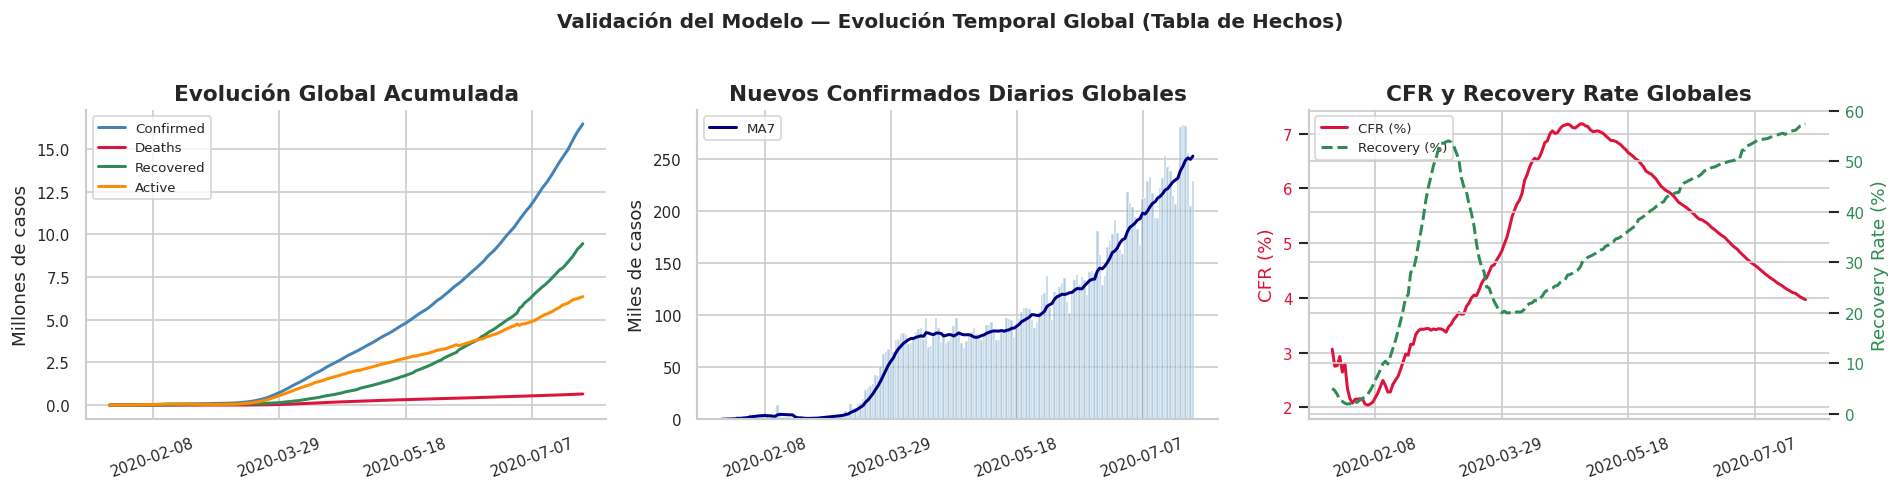


  Sanity check visual superado: las curvas siguen el patrón epidemiológico esperado.


In [15]:
# ── Evolución global acumulada (sanity check) ─────────────────────────────────
global_daily = (
    df_hechos.groupby('Date')[NUM_COLS]
    .sum().reset_index()
)
global_daily['CFR_global']      = global_daily['Deaths']    / global_daily['Confirmed'] * 100
global_daily['Recovery_global'] = global_daily['Recovered'] / global_daily['Confirmed'] * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Panel 1: Curvas acumuladas
for col, color in zip(NUM_COLS, COLORS):
    axes[0].plot(global_daily['Date'], global_daily[col] / 1e6,
                 label=col, color=color, linewidth=1.8)
axes[0].set_title('Evolución Global Acumulada')
axes[0].set_ylabel('Millones de casos')
axes[0].legend(fontsize=8)
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(5))
axes[0].tick_params(axis='x', rotation=20)

# Panel 2: Nuevos casos diarios (MA7)
new_daily = (
    df_hechos.groupby('Date')['New_Confirmed'].sum().reset_index()
)
new_daily['MA7'] = new_daily['New_Confirmed'].rolling(7, min_periods=1).mean()
axes[1].bar(new_daily['Date'], new_daily['New_Confirmed'] / 1e3,
            color='steelblue', alpha=0.4, width=1)
axes[1].plot(new_daily['Date'], new_daily['MA7'] / 1e3,
             color='navy', linewidth=1.8, label='MA7')
axes[1].set_title('Nuevos Confirmados Diarios Globales')
axes[1].set_ylabel('Miles de casos')
axes[1].legend(fontsize=8)
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(5))
axes[1].tick_params(axis='x', rotation=20)

# Panel 3: CFR y Recovery Rate globales en el tiempo
ax_cfr = axes[2]
ax_rec = ax_cfr.twinx()
ax_cfr.plot(global_daily['Date'], global_daily['CFR_global'],
            color='crimson', linewidth=1.8, label='CFR (%)')
ax_rec.plot(global_daily['Date'], global_daily['Recovery_global'],
            color='seagreen', linewidth=1.8, linestyle='--', label='Recovery (%)')
ax_cfr.set_title('CFR y Recovery Rate Globales')
ax_cfr.set_ylabel('CFR (%)', color='crimson')
ax_rec.set_ylabel('Recovery Rate (%)', color='seagreen')
ax_cfr.tick_params(axis='y', labelcolor='crimson')
ax_rec.tick_params(axis='y', labelcolor='seagreen')
lines1, lbl1 = ax_cfr.get_legend_handles_labels()
lines2, lbl2 = ax_rec.get_legend_handles_labels()
ax_cfr.legend(lines1 + lines2, lbl1 + lbl2, fontsize=8, loc='upper left')
axes[2].xaxis.set_major_locator(mticker.MaxNLocator(5))
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('Validación del Modelo — Evolución Temporal Global (Tabla de Hechos)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n  Sanity check visual superado: las curvas siguen el patrón epidemiológico esperado.')

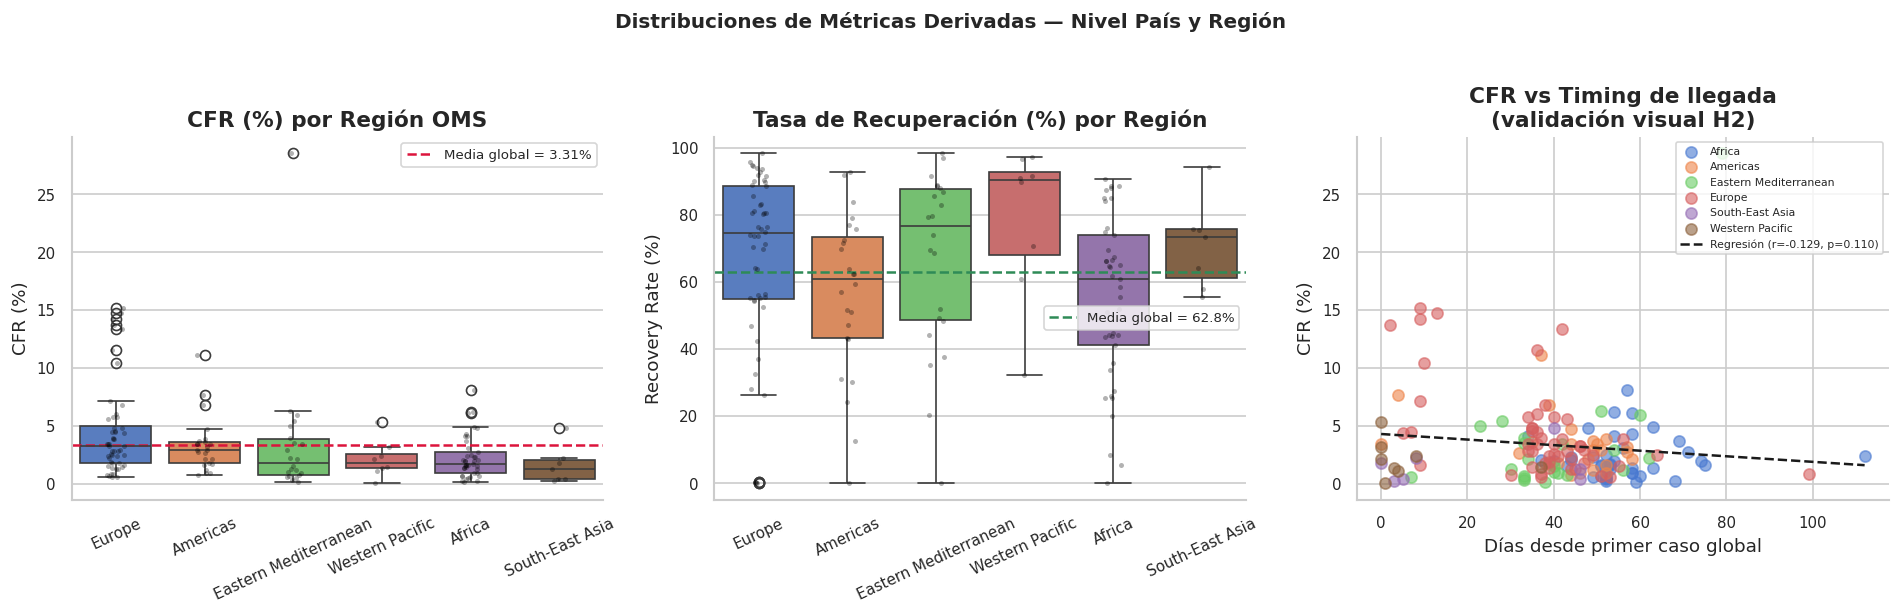

In [16]:
# ── Distribuciones de métricas clave por región ───────────────────────────────
region_order = (
    df_pais.groupby('WHO Region')['CFR'].median()
    .sort_values(ascending=False).index.tolist()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# CFR por región
sns.boxplot(data=df_pais, x='WHO Region', y='CFR',
            order=region_order, palette='muted', ax=axes[0])
sns.stripplot(data=df_pais, x='WHO Region', y='CFR',
              order=region_order, color='black', alpha=0.3, size=3,
              jitter=True, ax=axes[0])
axes[0].axhline(df_pais['CFR'].mean(), color='crimson', ls='--', lw=1.5,
                label=f'Media global = {df_pais["CFR"].mean():.2f}%')
axes[0].set_title('CFR (%) por Región OMS')
axes[0].set_xlabel('')
axes[0].set_ylabel('CFR (%)')
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend(fontsize=8)

# Recovery Rate por región
sns.boxplot(data=df_pais, x='WHO Region', y='Recovery_Rate',
            order=region_order, palette='muted', ax=axes[1])
sns.stripplot(data=df_pais, x='WHO Region', y='Recovery_Rate',
              order=region_order, color='black', alpha=0.3, size=3,
              jitter=True, ax=axes[1])
axes[1].axhline(df_pais['Recovery_Rate'].mean(), color='seagreen', ls='--', lw=1.5,
                label=f'Media global = {df_pais["Recovery_Rate"].mean():.1f}%')
axes[1].set_title('Tasa de Recuperación (%) por Región')
axes[1].set_xlabel('')
axes[1].set_ylabel('Recovery Rate (%)')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend(fontsize=8)

# Correlación CFR vs Days_from_start (refuerzo visual de H2)
for region, grp in df_pais.dropna(subset=['Days_from_start']).groupby('WHO Region'):
    axes[2].scatter(grp['Days_from_start'], grp['CFR'],
                    label=region, alpha=0.6, s=45)
slope_v, intercept_v, r_v, p_v, _ = stats.linregress(
    df_pais['Days_from_start'].dropna(),
    df_pais.loc[df_pais['Days_from_start'].notna(), 'CFR']
)
xv = np.linspace(0, df_pais['Days_from_start'].max(), 200)
axes[2].plot(xv, intercept_v + slope_v * xv, 'k--', lw=1.5,
             label=f'Regresión (r={r_v:.3f}, p={p_v:.3f})')
axes[2].set_title('CFR vs Timing de llegada\n(validación visual H2)')
axes[2].set_xlabel('Días desde primer caso global')
axes[2].set_ylabel('CFR (%)')
axes[2].legend(fontsize=6.5, loc='upper right')

plt.suptitle('Distribuciones de Métricas Derivadas — Nivel País y Región',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

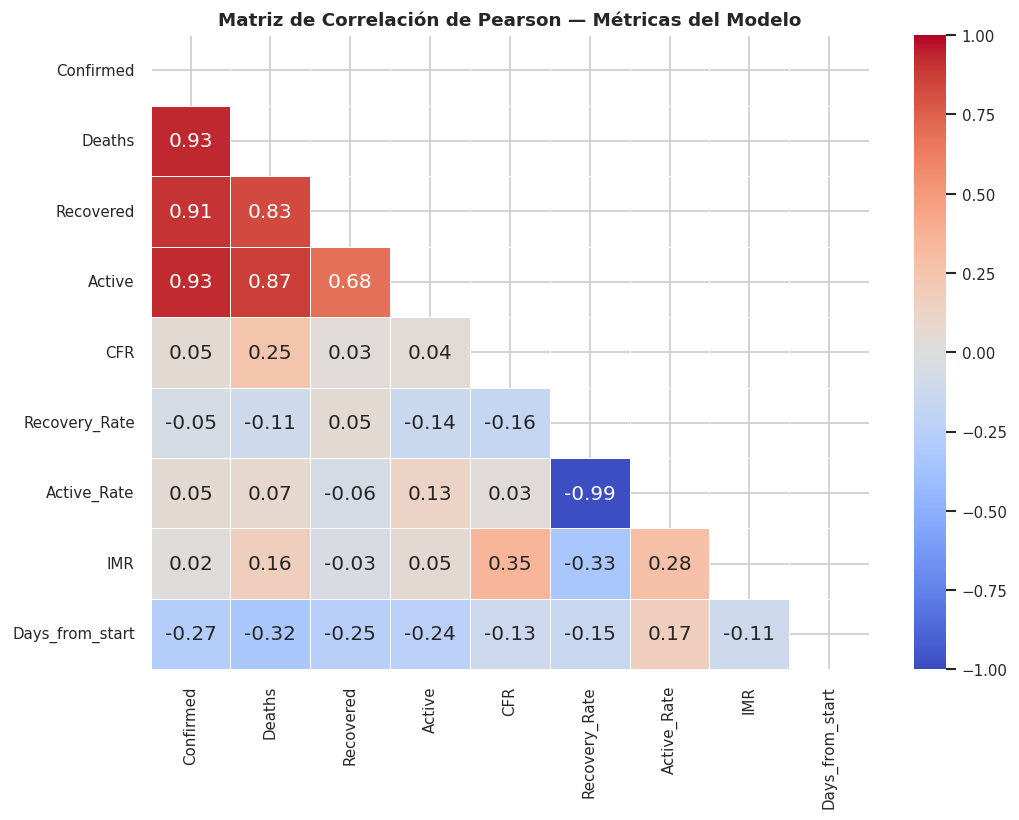


Correlaciones más fuertes con CFR (Pearson):
IMR                0.345219
Deaths             0.246884
Recovery_Rate     -0.164483
Days_from_start   -0.129138
Confirmed          0.047234
Active             0.043666
Recovered          0.027842
Active_Rate        0.025772


In [20]:
# ── Matriz de correlación de Spearman (métricas del snapshot) ─────────────────
cols_corr = ['Confirmed','Deaths','Recovered','Active',
             'CFR','Recovery_Rate','Active_Rate','IMR','Days_from_start']

corr_matrix = df_pais[cols_corr].corr(method='pearson')

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Matriz de Correlación de Pearson — Métricas del Modelo',
             fontsize=11)
plt.tight_layout()
plt.show()

print('\nCorrelaciones más fuertes con CFR (Pearson):')
cfr_corr = corr_matrix['CFR'].drop('CFR').sort_values(key=abs, ascending=False)
print(cfr_corr.to_string())

### 7.3 Exportación de tablas

In [18]:
import os
os.makedirs('../Data/Processed', exist_ok=True)

# ── Tabla de hechos completa ──────────────────────────────────────────────────
df_hechos.to_csv('../Data/Processed/hechos_covid_diario.csv', index=False)

# ── Snapshot por país ─────────────────────────────────────────────────────────
df_pais.to_csv('../Data/Processed/dim_pais_snapshot.csv', index=False)

# ── Agregado regional ─────────────────────────────────────────────────────────
df_region.to_csv('../Data/Processed/dim_region.csv', index=False)

# ── Dimensión fecha ───────────────────────────────────────────────────────────
dim_fecha.to_csv('../Data/Processed/dim_fecha.csv', index=False)

# ── Tabla de variables del modelo (documentación) ────────────────────────────
df_variables.to_csv('../Data/Processed/diccionario_modelo.csv', index=False)

print('Archivos exportados:')
for f in os.listdir('../Data/Processed'):
    size = os.path.getsize(f'../Data/Processed/{f}') / 1024
    print(f'   Data/Processed/{f:<45} {size:>7.1f} KB')
print()

Archivos exportados:
   Data/Processed/diccionario_modelo.csv                            1.5 KB
   Data/Processed/dim_fecha.csv                                     8.1 KB
   Data/Processed/dim_pais_snapshot.csv                            16.2 KB
   Data/Processed/dim_region.csv                                    1.0 KB
   Data/Processed/hechos_covid_diario.csv                        5345.7 KB



---
## 8. Conclusiones de la Fase 3

### 8.1 Resumen de decisiones de limpieza

| Problema | Decisión | Justificación |
|---|---|---|
| `Province/State` 70.1% nulo | Imputar con `Country/Region` | El análisis opera a nivel país; los nulos son estructurales, no errores |
| Valores negativos en conteos | Clip a 0 | No pueden existir casos negativos; son correcciones de reporte |
| Inconsistencia C ≠ D+R+A | Documentar, no corregir | Las diferencias son pequeñas y de origen en el timing de reporte |
| Outliers estadísticos (IQR) | Conservar | Son países con alta carga real; eliminarlos sesgaría el análisis |
| Países con <500 casos en comparativos | Excluir del snapshot | Evita CFRs artificialmente extremas (1 muerte = 100% CFR) |

### 8.2 Modelo dimensional resultante

Se generaron **4 tablas** estructuradas para Power BI (esquema estrella):

1. **`hechos_covid_diario.csv`** — 49,068 filas, 15 columnas. Tabla de hechos con granularidad País/Provincia × Día.
2. **`dim_pais_snapshot.csv`** — 154 países con métricas al corte final y variables derivadas.
3. **`dim_region.csv`** — 6 regiones OMS con agregados epidemiológicos.
4. **`dim_fecha.csv`** — 188 días con atributos de calendario para filtros temporales en Power BI.

### 8.3 Variables derivadas y su vínculo con KPIs e hipótesis

| Variable derivada | Alimenta KPI | Hipótesis relacionada | Pregunta clave |
|---|---|---|---|
| `CFR` | KPI 1 | H1 (ANOVA, confirmada) | P1: disparidad en letalidad |
| `Recovery_Rate` | KPI 2 | H1 | P3: gestión de recuperación |
| `Active_Rate` | KPI 3 | H1 | P1: carga sanitaria activa |
| `IMR` | KPI 4 | H1, H2 | P1, P3 |
| `Days_from_start` | KPI 5 | H2 (Pearson, no confirmada) | P2: oleadas y timing |
| `MA7_New_Confirmed` | KPI 6 | H2 | P2: aceleración de oleadas |
| `MA7_New_Deaths` | KPI 7 | H1, H2 | P1, P2 |